In [2]:
import warnings
warnings.filterwarnings("ignore")

import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Data Loading

In [3]:
df= pd.read_csv("STOFSatl_hydro.csv")

df.head()

,time_UTC,observed_data,forecast_data,offset,x,y,station_id,agency,storm,year,time_UTC_dt
0,2004-08-09 00:00:00,NaN,NaN,NaN,-79.962864,32.890452,21720677,USGS,CHARLEY,2004,0.0
1,2004-08-09 01:00:00,-1.874,NaN,NaN,-79.962864,32.890452,21720677,USGS,CHARLEY,2004,60.0
2,2004-08-09 02:00:00,-1.964,NaN,NaN,-79.962864,32.890452,21720677,USGS,CHARLEY,2004,120.0
3,2004-08-09 03:00:00,-1.554,NaN,NaN,-79.962864,32.890452,21720677,USGS,CHARLEY,2004,180.0
4,2004-08-09 04:00:00,-0.674,NaN,NaN,-79.962864,32.890452,21720677,USGS,CHARLEY,2004,240.0


In [4]:
df.dropna(inplace= True)

In [5]:
df['station_id']= df['station_id'].astype(str)

In [6]:
df['storm'].value_counts()

storm
HARVEY     82834
IDALIA     61251
HERMINE    51887
IAN        41491
MATTHEW    37523
IDA        34993
CHARLEY    17935
Name: count, dtype: int64

In [7]:
df_harvey= df[df['storm']=='HARVEY']
df_idalia= df[df['storm']=='IDALIA']
df_hermine= df[df['storm']=='HERMINE']
df_matthew= df[df['storm']=='MATTHEW']
df_ian= df[df['storm']=='IAN']
df_ida= df[df['storm']=='IDA']
df_charley= df[df['storm']=='CHARLEY']

### Data Processing

In [8]:
def stations_remover(df, count):
    station_counts= df['station_id'].value_counts()
    matching_station_ids= station_counts[station_counts == count].index

    filtered_df= df[df['station_id'].isin(matching_station_ids)]

    return filtered_df

In [9]:
# df_harvey['station_id'].value_counts().value_counts() #263 is the prevalent
# df_idalia['station_id'].value_counts().value_counts() #168 is the prevalent
# df_hermine['station_id'].value_counts().value_counts() #173 is the prevalent
# df_matthew['station_id'].value_counts().value_counts() #136
# df_ian['station_id'].value_counts().value_counts() #143
# df_ida['station_id'].value_counts().value_counts() #107
# df_charley['station_id'].value_counts().value_counts() #144

df_harvey= stations_remover(df_harvey, 263)
df_idalia= stations_remover(df_idalia, 168)
df_hermine= stations_remover(df_hermine, 173)
df_matthew= stations_remover(df_matthew, 136)
df_ian= stations_remover(df_ian, 143)
df_ida= stations_remover(df_ida, 107)
df_charley= stations_remover(df_charley, 144)

In [10]:
df_harvey['station_id'].value_counts().value_counts()

count
263    254
Name: count, dtype: int64

#### Data Plotting

In [11]:
def plot_offsets_by_station(df, df_name):

    folder_name = df_name
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    grouped = df.groupby('station_id')

    for station_id, group in grouped:
        plt.figure(figsize=(10, 6))
        
        plt.plot(group['time_UTC'], group['offset'], linestyle='-', label=f'Station {station_id}')
        
        plt.xlabel('Time')
        plt.ylabel('Offset')
        plt.title(f'Offset vs Time for Station {station_id}')
        plt.gca().set_xticks(group['time_UTC'][::max(1, len(group) // 10)])  # Show fewer x-axis labels (adjust as needed)
        plt.xticks(fontsize= 4)

        plot_filename = f'{folder_name}/station_{station_id}.png'
        plt.savefig(plot_filename)
        plt.close()

In [12]:
# plot_offsets_by_station(df_harvey, 'Harvey')
# plot_offsets_by_station(df_idalia, 'Idalia')
# plot_offsets_by_station(df_hermine, 'Hermine')
# plot_offsets_by_station(df_matthew, 'Matthew')
# plot_offsets_by_station(df_ian, 'Ian')
# plot_offsets_by_station(df_ida, 'Ida')
# plot_offsets_by_station(df_charley, 'Charley')

#### Abnormal Stations Removal

In [13]:
df_harvey.shape

(66802, 11)

In [14]:
dfs= [df_harvey, df_idalia, df_hermine, df_matthew, df_ian, df_ida, df_charley]
stations_to_remove= ['85670', '76030', '76065']

for idx, df in enumerate(dfs):
    dfs[idx] = df[~df['station_id'].isin(stations_to_remove)]

df_harvey, df_idalia, df_hermine, df_matthew, df_ian, df_ida, df_charley= dfs

In [15]:
df_harvey.shape

(66276, 11)

In [16]:
## To follow a matrix format, we will isolate the 105 points around the storm surge date, so that we would have a 
## (5, 21) matrix to input to our model

#### Hurricanes' Data Subsets

In [17]:
time_utc_harvey= df_harvey['time_UTC'].sort_values().drop_duplicates().tolist()

print(len(time_utc_harvey))
print(time_utc_harvey.index('2017-08-28 12:00:00'))

time_utc_harvey= time_utc_harvey[127:232]

print(len(time_utc_harvey))

263
179
105


In [18]:
time_utc_idalia= df_idalia['time_UTC'].sort_values().drop_duplicates().tolist()

print(len(time_utc_idalia))
print(time_utc_idalia.index('2023-08-30 12:00:00'))

time_utc_idalia= time_utc_idalia[37:142]

print(len(time_utc_idalia))

168
89
105


In [19]:
time_utc_charley= df_charley['time_UTC'].sort_values().drop_duplicates().tolist()

print(len(time_utc_charley))
print(time_utc_charley.index('2004-08-13 12:00:00'))

time_utc_charley= time_utc_charley[39:144]

print(len(time_utc_charley))

144
95
105


In [20]:
time_utc_matthew= df_matthew['time_UTC'].sort_values().drop_duplicates().tolist()

print(len(time_utc_matthew))
print(time_utc_matthew.index('2016-10-05 12:00:00'))

time_utc_matthew= time_utc_matthew[7:112] 

print(len(time_utc_matthew))

136
59
105


In [21]:
time_utc_ian= df_ian['time_UTC'].sort_values().drop_duplicates().tolist()

print(len(time_utc_ian))
print(time_utc_ian.index('2022-09-29 12:00:00'))

time_utc_ian= time_utc_ian[38:143]

print(len(time_utc_ian))

143
107
105


In [22]:
time_utc_hermine= df_hermine['time_UTC'].sort_values().drop_duplicates().tolist()

print(len(time_utc_hermine))
print(time_utc_hermine.index('2016-09-02 12:00:00'))

time_utc_hermine= time_utc_hermine[61:166]

print(len(time_utc_hermine))

173
113
105


In [23]:
time_utc_ida= df_ida['time_UTC'].sort_values().drop_duplicates().tolist()

print(len(time_utc_ida))
print(time_utc_ida.index('2021-08-29 12:00:00'))

time_utc_ida= time_utc_ida[2:107]

print(len(time_utc_ida))

107
71
105


#### Dataframes Filtering

In [24]:
df_harvey= df_harvey[df_harvey['time_UTC'].isin(time_utc_harvey)]

df_harvey

,time_UTC,observed_data,forecast_data,offset,x,y,station_id,agency,storm,year,time_UTC_dt
126024,2017-08-26 08:00:00,4.175,4.454,0.279,-70.872831,42.815647,01100870,USGS,HARVEY,2017,7680.0
126025,2017-08-26 09:00:00,2.855,3.281,0.426,-70.872831,42.815647,01100870,USGS,HARVEY,2017,7740.0
126026,2017-08-26 10:00:00,1.215,1.626,0.411,-70.872831,42.815647,01100870,USGS,HARVEY,2017,7800.0
126027,2017-08-26 11:00:00,-0.455,-0.269,0.186,-70.872831,42.815647,01100870,USGS,HARVEY,2017,7860.0
126028,2017-08-26 12:00:00,-2.055,-1.836,0.219,-70.872831,42.815647,01100870,USGS,HARVEY,2017,7920.0
...,...,...,...,...,...,...,...,...,...,...,...
209092,2017-08-30 12:00:00,-0.442,-0.359,0.083,-72.380044,18.537800,STOFS_ptpr,IOC-UNESCO,HARVEY,2017,13680.0
209093,2017-08-30 13:00:00,-0.573,-0.388,0.185,-72.380044,18.537800,STOFS_ptpr,IOC-UNESCO,HARVEY,2017,13740.0
209094,2017-08-30 14:00:00,-0.471,-0.363,0.108,-72.380044,18.537800,STOFS_ptpr,IOC-UNESCO,HARVEY,2017,13800.0
209095,2017-08-30 15:00:00,-0.363,-0.262,0.101,-72.380044,18.537800,STOFS_ptpr,IOC-UNESCO,HARVEY,2017,13860.0


In [25]:
df_charley= df_charley[df_charley['time_UTC'].isin(time_utc_charley)]
df_idalia= df_idalia[df_idalia['time_UTC'].isin(time_utc_idalia)]
df_matthew= df_matthew[df_matthew['time_UTC'].isin(time_utc_matthew)]
df_ian= df_ian[df_ian['time_UTC'].isin(time_utc_ian)]
df_hermine= df_hermine[df_hermine['time_UTC'].isin(time_utc_hermine)]
df_ida= df_ida[df_ida['time_UTC'].isin(time_utc_ida)]

In [26]:
def filter_data(df, storm):
    global_mean = df['offset'].mean()
    global_std = df['offset'].std()
    threshold = 3 * global_std

    print(f"Threshold for {storm}: {threshold}")
    print('Unique stations count before filtering: ', df['station_id'].nunique())
    def filter_outliers(df):
        station_mean = df['offset'].mean()
        return df[(df['offset'] >= station_mean - threshold) & (df['offset'] <= station_mean + threshold)]
    
    filtered_df = df.groupby('station_id').apply(filter_outliers).reset_index(drop=True)

    station_counts = filtered_df['station_id'].value_counts()
    valid_stations = station_counts[station_counts >= 105].index
    
    filtered_df = filtered_df[filtered_df['station_id'].isin(valid_stations)]

    print('Unique stations count after filtering: ', filtered_df['station_id'].nunique())
    print('-------------------------------------------------\n')
    return filtered_df

In [27]:
df_harvey= filter_data(df_harvey, 'Harvey')
df_charley= filter_data(df_charley, 'Charley')
df_idalia= filter_data(df_idalia, 'Idalia')
df_matthew= filter_data(df_matthew, 'Matthew')
df_ian= filter_data(df_ian, 'Ian')
df_hermine= filter_data(df_hermine, 'Hermine')
df_ida= filter_data(df_ida, 'Ida')

Threshold for Harvey: 3.7485517737001692
Unique stations count before filtering:  252
Unique stations count after filtering:  247
-------------------------------------------------

Threshold for Charley: 5.147744186473844
Unique stations count before filtering:  108
Unique stations count after filtering:  108
-------------------------------------------------

Threshold for Idalia: 4.273041072226937
Unique stations count before filtering:  308
Unique stations count after filtering:  304
-------------------------------------------------

Threshold for Matthew: 3.0491354157344244
Unique stations count before filtering:  244
Unique stations count after filtering:  236
-------------------------------------------------

Threshold for Ian: 3.429026150142319
Unique stations count before filtering:  256
Unique stations count after filtering:  250
-------------------------------------------------

Threshold for Hermine: 3.536065440952572
Unique stations count before filtering:  270
Unique statio

In [28]:
df_harvey['time_UTC'].value_counts() # each time_UTC of the 105 is repeated 246 times, the number of stations
                                     # after filtering, therefore there are not issues

time_UTC
2017-08-26 08:00:00    247
2017-08-28 13:00:00    247
2017-08-29 13:00:00    247
2017-08-29 12:00:00    247
2017-08-29 11:00:00    247
                      ... 
2017-08-27 16:00:00    247
2017-08-27 15:00:00    247
2017-08-27 14:00:00    247
2017-08-27 13:00:00    247
2017-08-30 16:00:00    247
Name: count, Length: 105, dtype: int64

#### Merged Dataframe

In [29]:
dfs= [df_harvey, df_charley, df_idalia, df_matthew, df_ian, df_hermine, df_ida]

merged_df= pd.concat(dfs, ignore_index= True)

In [30]:
merged_df['time_UTC'].nunique() # 105 time_UTC values per hurricane

735

In [31]:
merged_df['station_id'].nunique()

507

In [32]:
df = merged_df.drop(['forecast_data', 'observed_data', 'time_UTC_dt'], axis=1)

df['station_id'] = df['station_id'] + '_' + df['storm']

df['row_num'] = df.groupby('station_id').cumcount()

pivot_df = df.pivot_table(values='offset', index='row_num', columns='station_id', aggfunc='first')

In [33]:
pivot_df

station_id,01100870_HARVEY,01100870_IAN,01100870_IDA,01100870_MATTHEW,01194750_HARVEY,01194750_IAN,01194750_IDA,01194750_MATTHEW,01194796_HARVEY,01194796_IAN,...,STOFS_setp1_IDALIA,STOFS_stdpr_IDALIA,STOFS_stlu2_IDALIA,STOFS_stlu3_IDALIA,STOFS_stlu_IDALIA,STOFS_vieq_HERMINE,STOFS_vieq_IDALIA,STOFS_vieq_MATTHEW,STOFS_yabu_HERMINE,STOFS_yabu_IDALIA
row_num,,,,,,,,,,,,,,,,,,,,,
0,0.279,-0.591,-1.054,0.157,-0.100,0.003,-0.589,-0.415,-0.313,0.125,...,0.712,0.035,0.076,0.122,0.202,-0.018,-0.060,0.094,0.087,-0.058
1,0.426,-0.334,-1.198,-0.001,-0.239,-0.095,-0.728,-0.448,-0.512,-0.026,...,0.606,-0.004,0.124,-0.158,0.186,-0.004,-0.041,-0.018,0.040,-0.040
2,0.411,-1.085,-1.145,-0.077,-0.278,-0.300,-0.738,-0.499,-0.623,-0.229,...,0.266,0.008,0.116,-0.213,0.108,-0.032,0.018,-0.014,-0.009,-0.021
3,0.186,-1.319,-1.001,-0.001,-0.259,-0.635,-0.698,-0.506,-0.558,-0.494,...,-0.050,-0.028,0.148,-0.212,0.048,-0.016,0.080,-0.030,-0.028,-0.050
4,0.219,-1.224,-0.793,-0.026,-0.338,-0.788,-0.711,-0.477,-0.512,-0.668,...,-0.287,-0.012,0.128,-0.222,-0.034,0.028,0.102,-0.030,0.012,0.022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,-0.203,0.675,-1.117,0.103,-0.710,0.137,-0.522,-0.043,-0.908,0.018,...,1.247,0.026,0.137,-0.359,0.243,-0.157,-0.030,0.165,-0.102,0.073
101,-0.203,-0.130,-1.060,0.028,-0.733,-0.057,-0.561,-0.080,-0.983,-0.191,...,0.813,-0.003,0.172,-0.357,0.142,-0.214,0.056,0.122,-0.147,0.012
102,-0.311,-0.186,-1.081,0.083,-0.751,-0.232,-0.598,-0.065,-1.012,-0.316,...,0.292,-0.047,0.108,-0.256,-0.089,-0.199,0.126,0.097,-0.196,0.152


In [34]:
df

,time_UTC,offset,x,y,station_id,agency,storm,year,row_num
0,2017-08-26 08:00:00,0.279,-70.872831,42.815647,01100870_HARVEY,USGS,HARVEY,2017,0
1,2017-08-26 09:00:00,0.426,-70.872831,42.815647,01100870_HARVEY,USGS,HARVEY,2017,1
2,2017-08-26 10:00:00,0.411,-70.872831,42.815647,01100870_HARVEY,USGS,HARVEY,2017,2
3,2017-08-26 11:00:00,0.186,-70.872831,42.815647,01100870_HARVEY,USGS,HARVEY,2017,3
4,2017-08-26 12:00:00,0.219,-70.872831,42.815647,01100870_HARVEY,USGS,HARVEY,2017,4
...,...,...,...,...,...,...,...,...,...
175135,2021-08-30 19:00:00,0.059,-67.308300,23.448300,STOFS_dstl_IDA,IOC-UNESCO,IDA,2021,100
175136,2021-08-30 20:00:00,0.079,-67.308300,23.448300,STOFS_dstl_IDA,IOC-UNESCO,IDA,2021,101
175137,2021-08-30 21:00:00,0.096,-67.308300,23.448300,STOFS_dstl_IDA,IOC-UNESCO,IDA,2021,102
175138,2021-08-30 22:00:00,0.118,-67.308300,23.448300,STOFS_dstl_IDA,IOC-UNESCO,IDA,2021,103


In [35]:
df[df['station_id']=='01100870_IAN']

,time_UTC,offset,x,y,station_id,agency,storm,year,row_num
93975,2022-09-26 15:00:00,-0.591,-70.872831,42.815647,01100870_IAN,USGS,IAN,2022,0
93976,2022-09-26 16:00:00,-0.334,-70.872831,42.815647,01100870_IAN,USGS,IAN,2022,1
93977,2022-09-26 17:00:00,-1.085,-70.872831,42.815647,01100870_IAN,USGS,IAN,2022,2
93978,2022-09-26 18:00:00,-1.319,-70.872831,42.815647,01100870_IAN,USGS,IAN,2022,3
93979,2022-09-26 19:00:00,-1.224,-70.872831,42.815647,01100870_IAN,USGS,IAN,2022,4
...,...,...,...,...,...,...,...,...,...
94075,2022-09-30 19:00:00,0.675,-70.872831,42.815647,01100870_IAN,USGS,IAN,2022,100
94076,2022-09-30 20:00:00,-0.130,-70.872831,42.815647,01100870_IAN,USGS,IAN,2022,101
94077,2022-09-30 21:00:00,-0.186,-70.872831,42.815647,01100870_IAN,USGS,IAN,2022,102
94078,2022-09-30 22:00:00,-0.248,-70.872831,42.815647,01100870_IAN,USGS,IAN,2022,103


#### Map

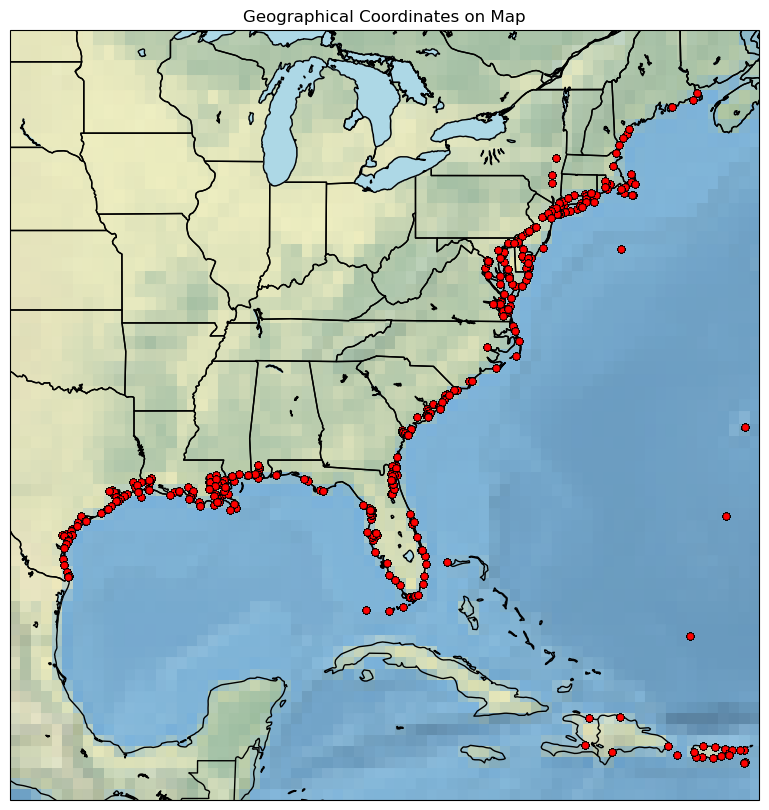

In [39]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import NaturalEarthFeature

unique_lats = df['y'].tolist()
unique_longs = df['x'].tolist()

def mapper():
    fig = plt.figure(figsize=(12, 10))
    ax = plt.axes(projection=ccrs.Mercator())
    
    # Adding features to the map
    ax.add_feature(cfeature.COASTLINE, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, edgecolor='black')
    ax.add_feature(cfeature.STATES, edgecolor='black')
    ax.set_extent([-100, -64, 16, 47], crs=ccrs.PlateCarree())

    # Setting map background color
    ax.stock_img()  # This adds a background image with natural features
    ax.add_feature(cfeature.LAND, color='0.8')  # Adding land with grey color
    ax.add_feature(cfeature.OCEAN, color='lightblue')  # Adding ocean with light blue color
    ax.add_feature(cfeature.LAKES, color='lightblue')  # Adding lakes with light blue color
    
    lake_borders = NaturalEarthFeature(category='physical', name='lakes', scale='10m', edgecolor='black', facecolor='none')
    ax.add_feature(lake_borders)
    
    return ax

ax = mapper()

ax.scatter(unique_longs, unique_lats, marker='o', color='red', 
           edgecolors='black', linewidths=0.3, zorder=10, s=25, transform=ccrs.PlateCarree())

plt.title('Geographical Coordinates on Map')
plt.show()

### Train-Test Split

#### Clustering

In [40]:
unique_stations = df[['station_id', 'x', 'y']].drop_duplicates()
unique_df = pd.DataFrame(unique_stations, columns=['station_id', 'x', 'y'])

len(unique_df)

1668

In [81]:
nclusters= int(len(unique_df)*0.05)

nclusters

83

In [82]:
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors

kmeans = KMeans(n_clusters= nclusters, random_state=42)
unique_df['cluster_id'] = kmeans.fit_predict(unique_df[['x','y']])

unique_df= unique_df.sort_values('cluster_id')

cmap = plt.cm.get_cmap('Set1')
colors = [cmap(i) for i in range(8)]
colors_hex = [mcolors.rgb2hex(c) for c in colors]
 
cluster_colors = {cluster_id: colors_hex[cluster_id % 8] for cluster_id in unique_df['cluster_id']}
unique_df['color'] = unique_df['cluster_id'].map(cluster_colors)

In [83]:
unique_df.head(10)

,station_id,x,y,cluster_id,color
120540,1194815_HERMINE,-72.349278,41.281333,0,#e41a1c
525,01304200_HARVEY,-72.306750,41.136639,0,#e41a1c
69405,01194796_MATTHEW,-72.345917,41.312598,0,#e41a1c
315,01194815_HARVEY,-72.349278,41.281333,0,#e41a1c
105,01194750_HARVEY,-72.384367,41.351483,0,#e41a1c
52290,8461490_IDALIA,-72.095556,41.371667,0,#e41a1c
79275,8461490_MATTHEW,-72.095556,41.371667,0,#e41a1c
79590,8510560_MATTHEW,-71.959444,41.048333,0,#e41a1c
11655,8510560_HARVEY,-71.959444,41.048333,0,#e41a1c
106785,8510560_IAN,-71.959444,41.048333,0,#e41a1c


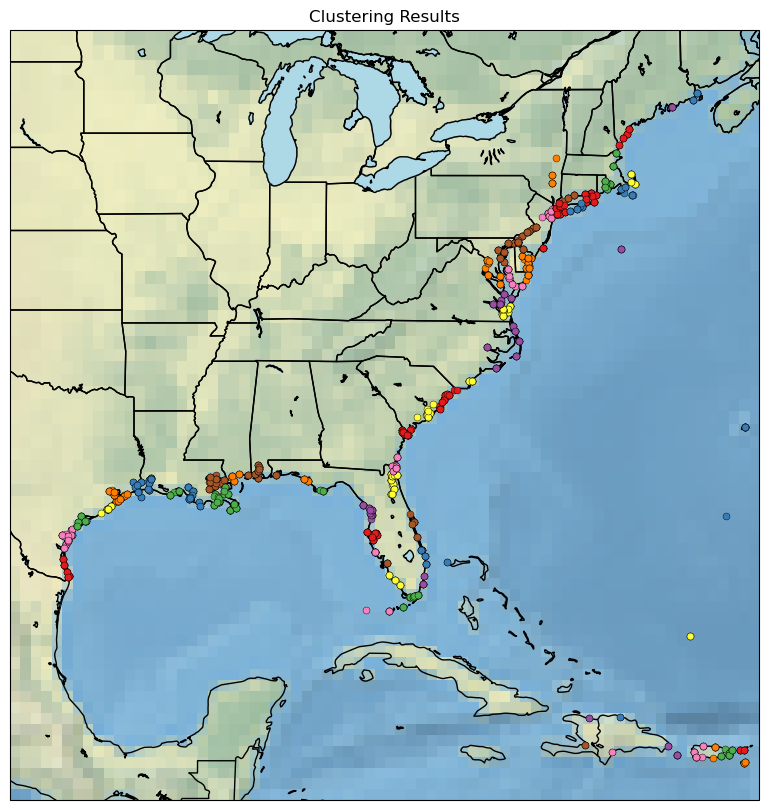

In [84]:
ax= mapper()

for i in range(len(unique_df)):
    x = unique_df['x'].iloc[i]
    y = unique_df['y'].iloc[i]
    ax.scatter(x, y, marker='o', color= unique_df['color'].iloc[i],
               edgecolors='black', linewidths=0.3, zorder= 10, s= 25, transform=ccrs.PlateCarree())    

plt.title('Clustering Results')
plt.show()

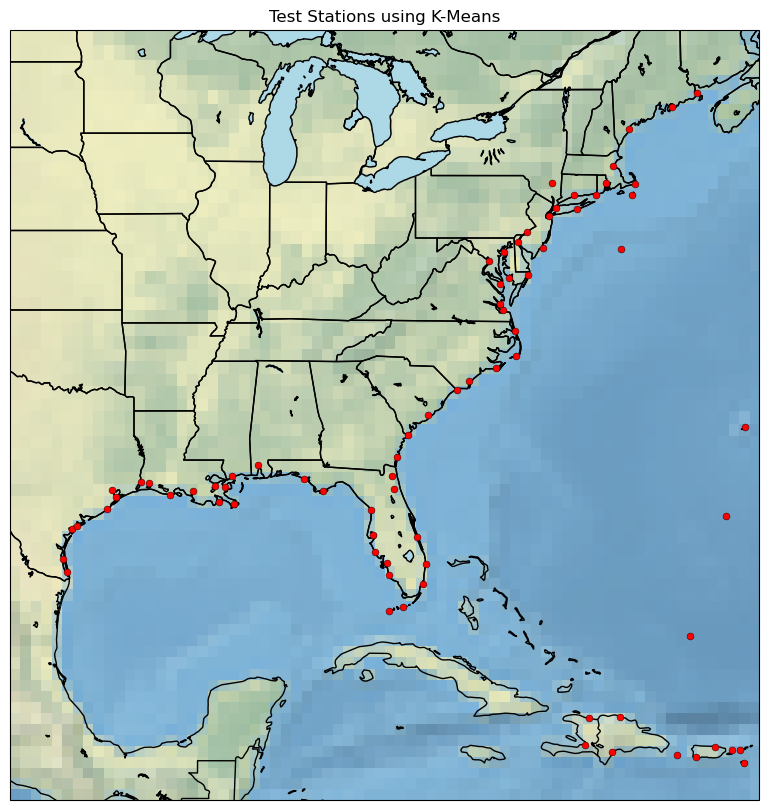

In [85]:
test_ids = []

grouped_df = unique_df.groupby('cluster_id')

for cluster_id, group in grouped_df:
    random_row = group.sample(1)
    new_station_id = random_row['station_id'].values[0]
    test_ids.append(new_station_id)

ax= mapper()
ktest_longs = []
ktest_lats= []

for i in test_ids:
    x, y= unique_df[unique_df['station_id']== i]['x'].values[0], unique_df[unique_df['station_id']== i]['y'].values[0]
    ktest_longs.append(x)
    ktest_lats.append(y)
    ax.scatter(x, y, marker='o', color= "red", 
               edgecolors='black', linewidths=0.3, zorder= 10, s= 25, transform=ccrs.PlateCarree())    

plt.title('Test Stations using K-Means')
plt.show()

In [86]:
len(ktest_longs)

83

In [87]:
station_counts = {}

for station_id in test_ids:
    count = df['station_id'].eq(station_id).sum()
    station_counts[station_id] = count

station_counts

{'411838071513000_HERMINE': 105,
 '08030540_IDA': 105,
 '8723970_HERMINE': 105,
 '9759938_HERMINE': 105,
 '8635750_HERMINE': 105,
 '8720226_IDALIA': 105,
 '8761955_IDALIA': 105,
 '8774513_CHARLEY': 105,
 '8659897_CHARLEY': 105,
 '2695540_CHARLEY': 105,
 'STOFS_calq_MATTHEW': 105,
 '8413320_MATTHEW': 105,
 '9751401_IAN': 105,
 '8447435_IDALIA': 105,
 '8737138_IDA': 105,
 '1376562_HARVEY': 105,
 '8726607_HARVEY': 105,
 'STOFS_sana_MATTHEW': 105,
 '8728690_HARVEY': 105,
 '8654467_MATTHEW': 105,
 '8570283_HARVEY': 105,
 'STOFS_dstl_MATTHEW': 105,
 '2251800_IDALIA': 105,
 'STOFS_dat2_IDALIA': 105,
 '8670870_HERMINE': 105,
 '7381600_HARVEY': 105,
 '8760721_HARVEY': 105,
 'STOFS_caph_HARVEY': 105,
 '8771013_HERMINE': 105,
 '0204289994_MATTHEW': 105,
 '8551762_IDALIA': 105,
 'STOFS_desh_MATTHEW': 105,
 '8779280_IAN': 105,
 '8722670_IDA': 105,
 '8443970_HERMINE': 105,
 '2310752_IDALIA': 105,
 '9755371_IAN': 105,
 '21720698_IDALIA': 105,
 'STOFS_dat3_MATTHEW': 105,
 '2299733_HERMINE': 105,
 '841

In [88]:
test_df = df[df['station_id'].isin(station_counts.keys())]
train_df = df[~df['station_id'].isin(station_counts.keys())]

print("Number of unique station_ids in test_df:", test_df['station_id'].nunique())
print("Number of unique station_ids in train_df:", train_df['station_id'].nunique())

Number of unique station_ids in test_df: 83
Number of unique station_ids in train_df: 1585


In [89]:
test_df.to_csv('test_df.csv', index=False)
train_df.to_csv('train_df.csv', index=False)

In [90]:
unique_df['cluster_id'].value_counts()

cluster_id
7     59
14    53
29    46
5     46
20    46
      ..
27     2
79     2
23     2
73     2
49     1
Name: count, Length: 83, dtype: int64